<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

*   Lukas Piedrahita
*   Carlos Rodríguez

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

###  Solución Ejercicio 1

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el conjunto de datos
wine = load_wine()

# 2. Convertirlo a un DataFrame de pandas para que sea más legible
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# 3. Añadir la columna de la variable objetivo (el tipo de vino)
df['target'] = wine.target

# Mostrar las primeras 5 filas
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [ ]:
# Seleccionamos nuestras 3 variables + la columna objetivo
df_sub = df[['alcohol', 'flavanoids', 'color_intensity', 'target']]

# Ver un resumen estadístico rápido
print(df_sub.describe())

          alcohol  flavanoids  color_intensity      target
count  178.000000  178.000000       178.000000  178.000000
mean    13.000618    2.029270         5.058090    0.938202
std      0.811827    0.998859         2.318286    0.775035
min     11.030000    0.340000         1.280000    0.000000
25%     12.362500    1.205000         3.220000    0.000000
50%     13.050000    2.135000         4.690000    1.000000
75%     13.677500    2.875000         6.200000    2.000000
max     14.830000    5.080000        13.000000    2.000000


In [ ]:
# Variables seleccionadas
features = ['alcohol', 'flavanoids', 'color_intensity']
X = df[features]

# A. StandardScaler -> Media=0, Desv. Est.=1
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

# B. MinMaxScaler -> Rango [0, 1]
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# C. RobustScaler -> Basado en Mediana e IQR (resistente a outliers)
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X)

# D. Z-Score manual
X_zscore = (X - X.mean()) / X.std()

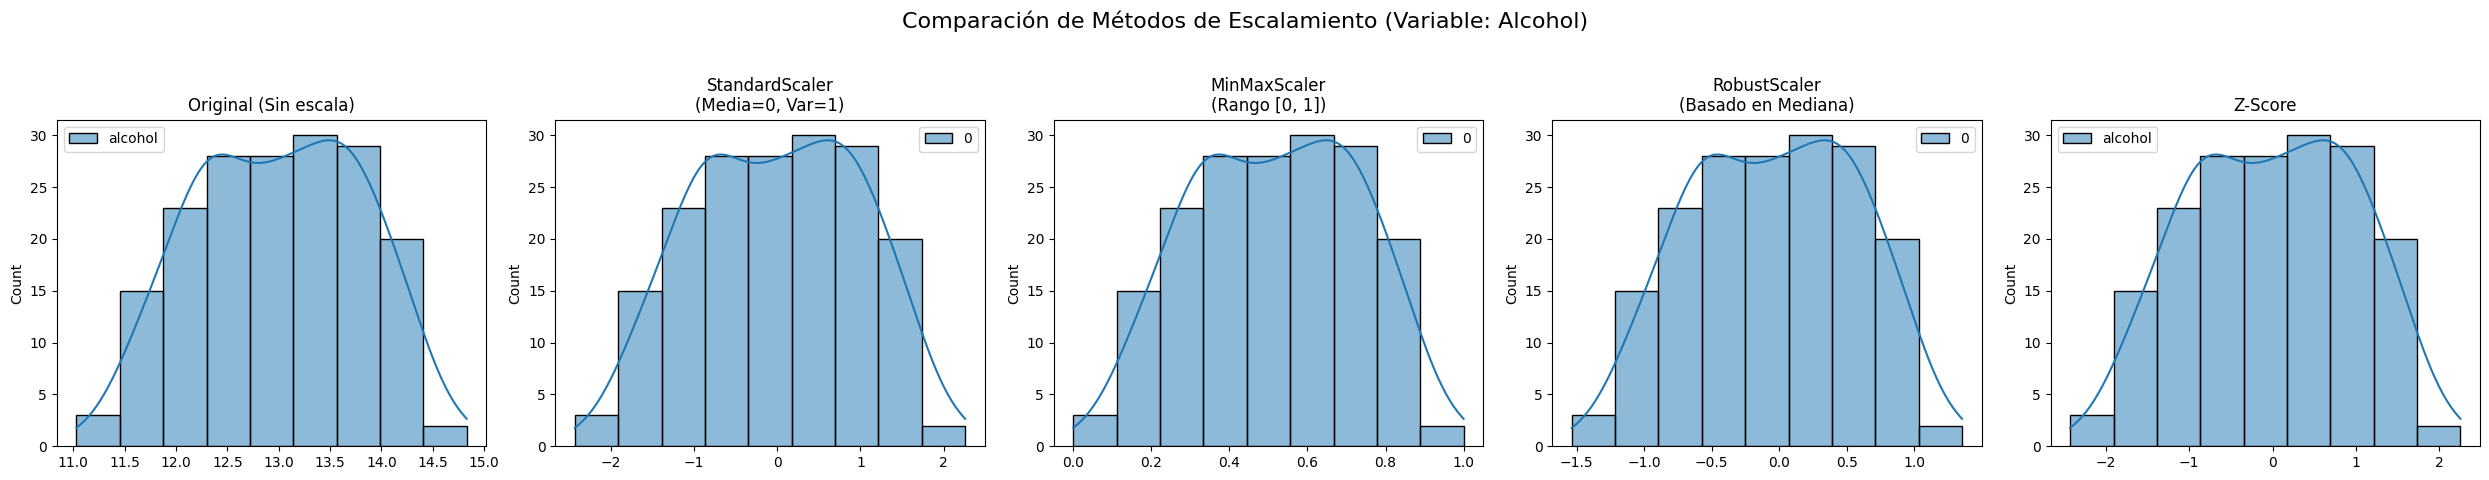

In [ ]:
# 1. Preparar los datos
data_alcohol = df[['alcohol']]

# 2. Aplicar las transformaciones
std_scaled = StandardScaler().fit_transform(data_alcohol)
minmax_scaled = MinMaxScaler().fit_transform(data_alcohol)
robust_scaled = RobustScaler().fit_transform(data_alcohol)
zscore_scaled = (data_alcohol - data_alcohol.mean()) / data_alcohol.std()

# 3. Configurar la visualización
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Comparación de Métodos de Escalamiento (Variable: Alcohol)', fontsize=16)

# Distribución Original
sns.histplot(data_alcohol, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original (Sin escala)')

# StandardScaler
sns.histplot(std_scaled, kde=True, ax=axes[1], color='blue')
axes[1].set_title('StandardScaler\n(Media=0, Var=1)')

# MinMaxScaler
sns.histplot(minmax_scaled, kde=True, ax=axes[2], color='green')
axes[2].set_title('MinMaxScaler\n(Rango [0, 1])')

# RobustScaler
sns.histplot(robust_scaled, kde=True, ax=axes[3], color='orange')
axes[3].set_title('RobustScaler\n(Basado en Mediana)')

# Z-Score
sns.histplot(zscore_scaled, kde=True, ax=axes[4], color='red')
axes[4].set_title('Z-Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis:**

> **StandardScaler y Z-Score** normalizan con media 0 y desviación 1, mientras **MinMaxScaler** escala al rango [0, 1] pero es vulnerable a valores atípicos. En contraste, **RobustScaler** utiliza la mediana y el rango intercuartílico, dandole a la escala una mayor protección a distorsiones por outliers. Para la variable alcohol, **RobustScaler** es la opción más recomendable, pues mantiene la integridad de la distribución frente a consumos extremos.



## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### Solución Ejercicio 2

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar el dataset
diabetes = load_diabetes()

# Crear DataFrame con las variables
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

# Agregar variable objetivo
df['target'] = diabetes.target

# Ver primeras filas
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
# Variables disponibles
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:
#Información sobre las variable disponibles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
# Variables seleccionadas para el análisis
features = ['bmi', 'bp', 's5']
X = df[features]
print(X.head())

        bmi        bp        s5
0  0.061696  0.021872  0.019907
1 -0.051474 -0.026328 -0.068332
2  0.044451 -0.005670  0.002861
3 -0.011595 -0.036656  0.022688
4 -0.036385  0.021872 -0.031988


In [ ]:
# Escalamiento
from sklearn.preprocessing import StandardScaler, RobustScaler

# Z-Score (Standard)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

# Robust
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

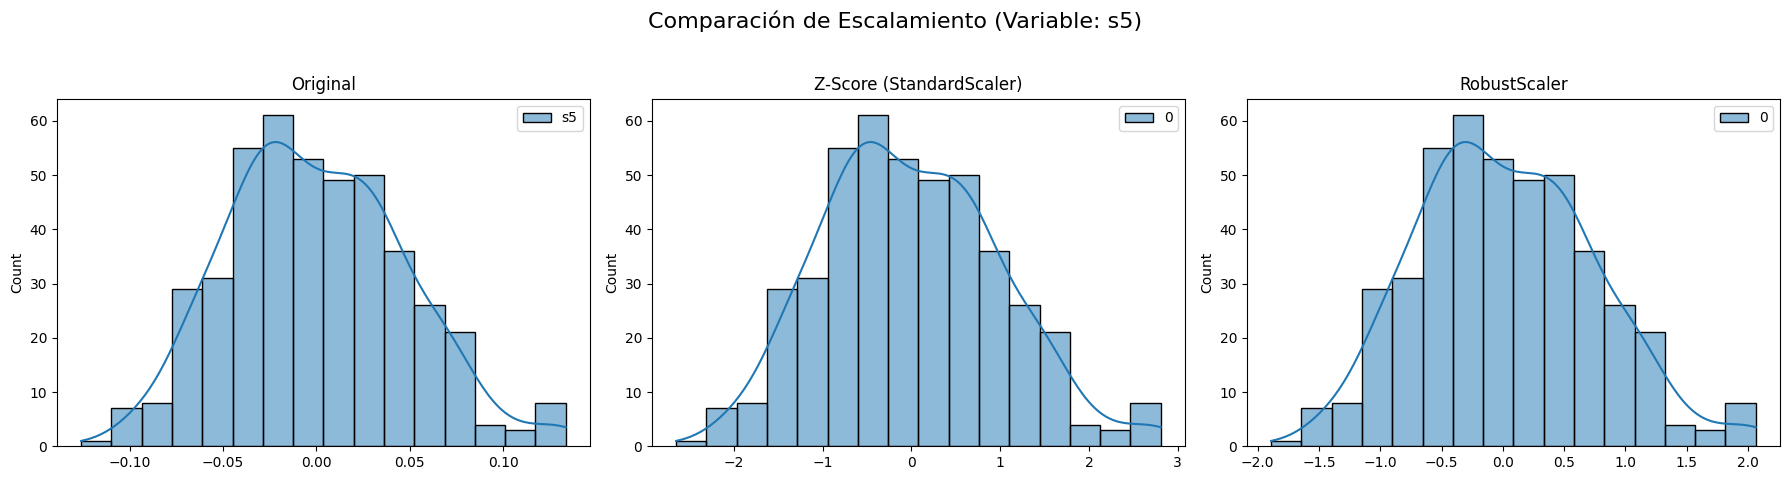

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar la variable
data_s5 = df[['s5']]

# 2. Aplicar transformaciones
zscore_scaled = StandardScaler().fit_transform(data_s5)
robust_scaled = RobustScaler().fit_transform(data_s5)

# 3. Configurar visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Escalamiento (Variable: s5)', fontsize=16)

# Distribución original
sns.histplot(data_s5, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')

# Z-Score (StandardScaler)
sns.histplot(zscore_scaled, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Z-Score (StandardScaler)')

# RobustScaler
sns.histplot(robust_scaled, kde=True, ax=axes[2], color='orange')
axes[2].set_title('RobustScaler')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis:**
>El método **Z-Score (StandardScaler)** ajusta los datos a media 0 y desviación 1, asumiendo normalidad. En cambio, **RobustScaler** emplea la mediana y el rango intercuartílico, protegiendo, en mayor medida, el análisis de valores atípicos. Se recomienda usar **RobustScaler** porque el progreso de la diabetes suele incluir casos extremos. Su aplicación ayuda a evitar sesgos por outliers, garantizando una escala más precisa y representativa para la mayoría de los pacientes.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### Solución Ejercicio 3

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import Normalizer

# Carga de datos
housing = fetch_california_housing()

# Crear DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Ver datos
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
# Identificar variables disponibles
print(f"", df.columns, "\n\n<--------------------------------------------------------------------->\n")
df.info()

 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object') 

<--------------------------------------------------------------------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
# Selección de variables
features = ['HouseAge', 'AveRooms', 'Population']
X = df[features]

In [ ]:
# Aplicación de Normalización (se aplica por fila)
transformer_l1 = Normalizer(norm='l1')
transformer_l2 = Normalizer(norm='l2')

# L1 → suma de valores absolutos = 1
normalizer_l1 = Normalizer(norm='l1')
X_l1 = normalizer_l1.fit_transform(X)

# L2 → norma euclidiana = 1
normalizer_l2 = Normalizer(norm='l2')
X_l2 = normalizer_l2.fit_transform(X)

# Conversión a DataFrame
X_l1 = pd.DataFrame(X_l1, columns=features)
X_l2 = pd.DataFrame(X_l2, columns=features)

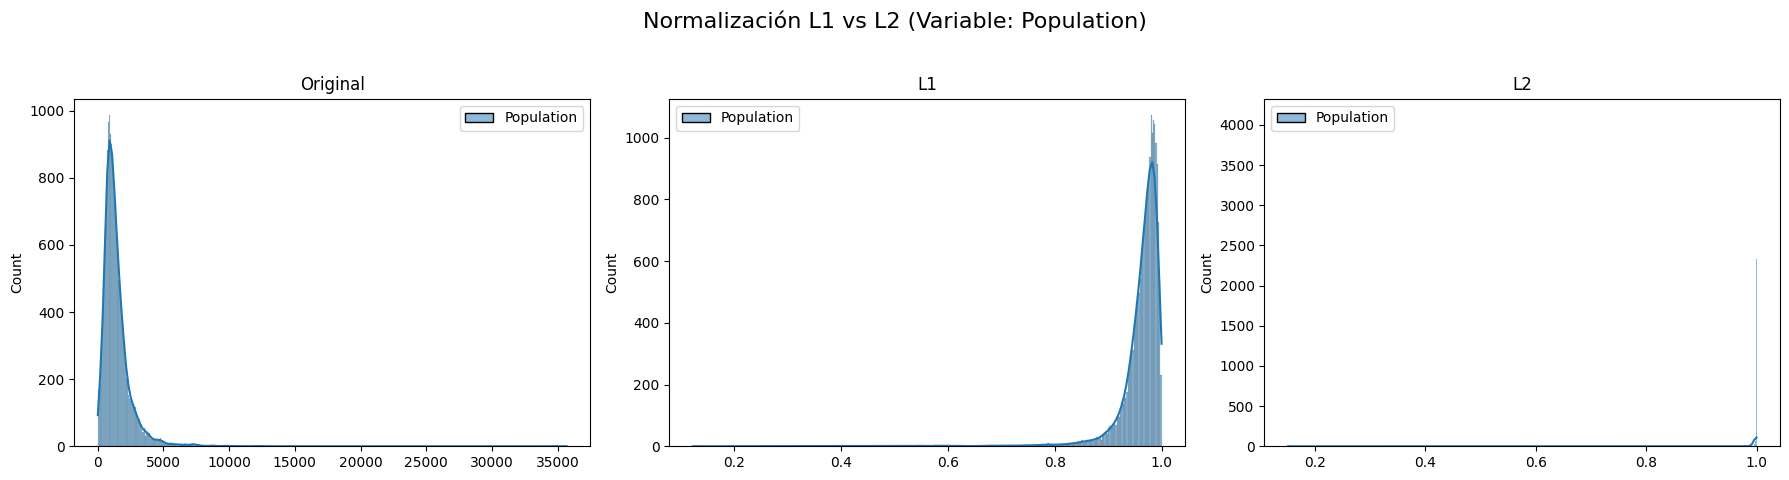

In [ ]:
# Variable a analizar
data_pop = df[['Population']]

# Datos normalizados (misma columna)
pop_l1 = X_l1[['Population']]
pop_l2 = X_l2[['Population']]

# Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Normalización L1 vs L2 (Variable: Population)', fontsize=16)

# Original
sns.histplot(data_pop, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')

# L1
sns.histplot(pop_l1, kde=True, ax=axes[1], color='blue')
axes[1].set_title('L1')

# L2
sns.histplot(pop_l2, kde=True, ax=axes[2], color='green')
axes[2].set_title('L2')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis:**
> La variable elegida presenta sesgo (cola a la derecha). Tras aplicar normalización L1 y L2, los datos se concentran cerca de 1, perdiendo su forma original, ya que estos métodos normalizan por fila (no columna) y transforman los valores en proporciones. L2 acentúa aún más este efecto al penalizar valores grandes. En este escenario, L2 es más recomendable ya que penaliza los valores más grandes, reduciendo el sesgo (en L1 aún se puede observar una cola, esta vez a la izquierda).

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### Solución Ejercicio 4

In [ ]:
from sklearn.datasets import load_diabetes

# Cargar Dataser
diabetes = load_diabetes()

# Convertir a DataFrame
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# Visualizar variables disponibles
print(f"", df.head(), "\n\n<--------------------------------------------------------------------->\n")
print(f"", df.columns, "\n\n<--------------------------------------------------------------------->\n")
df.info()

         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0   

<--------------------------------------------------------------------->

 Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object') 

<--------------------------------------------------------------------->

<class 'pandas.core.frame.DataFrame

In [ ]:
# Selección de variables
features = ['bmi', 's5']
X = df[features]

In [ ]:
from scipy.stats import boxcox

data = df['s5']
data_shifted = data - data.min() + 1

# Tranformaciones
# Logarítmica
log_trans = np.log(data_shifted)

# Logarítmica reflejada
reflected = data_shifted.max() - data_shifted + 1
log_reflect = np.log(reflected)

# Cuadrática
square_trans = data_shifted ** 2

# Box-Cox
boxcox_trans, lambda_ = boxcox(data_shifted)

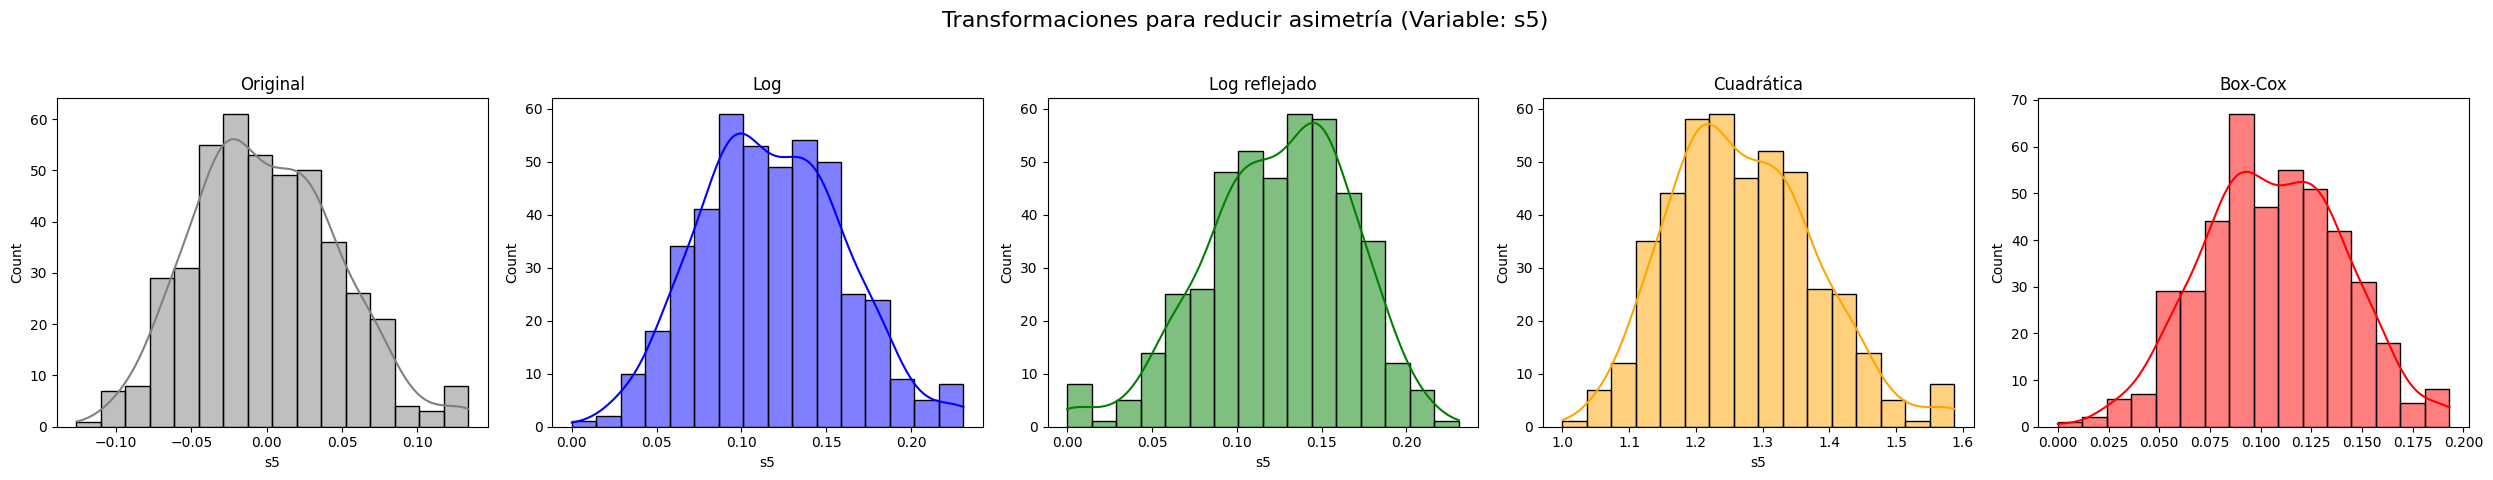

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Transformaciones para reducir asimetría (Variable: s5)', fontsize=16)

# Original
sns.histplot(data, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')

# Log
sns.histplot(log_trans, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Log')

# Log reflejado
sns.histplot(log_reflect, kde=True, ax=axes[2], color='green')
axes[2].set_title('Log reflejado')

# Cuadrática
sns.histplot(square_trans, kde=True, ax=axes[3], color='orange')
axes[3].set_title('Cuadrática')

# Box-Cox
sns.histplot(boxcox_trans, kde=True, ax=axes[4], color='red')
axes[4].set_title('Box-Cox')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis:**
> Los datos originales presentan una leve asimetría, en los cuáles la función logarítmica y la logarítmica reflejada (que gráficamente es notorio el "efecto espejo" que tiene en base a la logarítmica) no mejoran completamente esta asimetría, al igual que la transformación cuadrática. La que mejor trata de acercar los datos a una forma normal es la transformación Box-Cox, que es la más recomendada ya que en general es la que más busca dejar la distribución más normal.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### Solución Ejercicio 5

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import PowerTransformer

# Cargar dataset
heart = fetch_ucirepo(id=45)

# Datos (features y target)
X = heart.data.features
y = heart.data.targets

# Convertir a DataFrame
df = pd.DataFrame(X)
df['target'] = y

#Visualizar variables disponibles
print(f"", df.head(), "\n\n<--------------------------------------------------------------------->\n")
print(f"", df.columns, "\n\n<--------------------------------------------------------------------->\n")
df.info()

    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0   

<--------------------------------------------------------------------->

 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object') 

<--------------------------------------------------------------------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0

In [ ]:
# Selección de variables
features = ['chol', 'oldpeak']
X = df[features]

In [ ]:
data = df['oldpeak']
data_shifted = data - data.min() + 1

# Transformaciones
# Raíz cuadrada
sqrt_trans = np.sqrt(data_shifted)

# Recíproca
reciprocal_trans = 1 / data_shifted

# Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
yeojohnson_trans = pt.fit_transform(data.values.reshape(-1, 1))

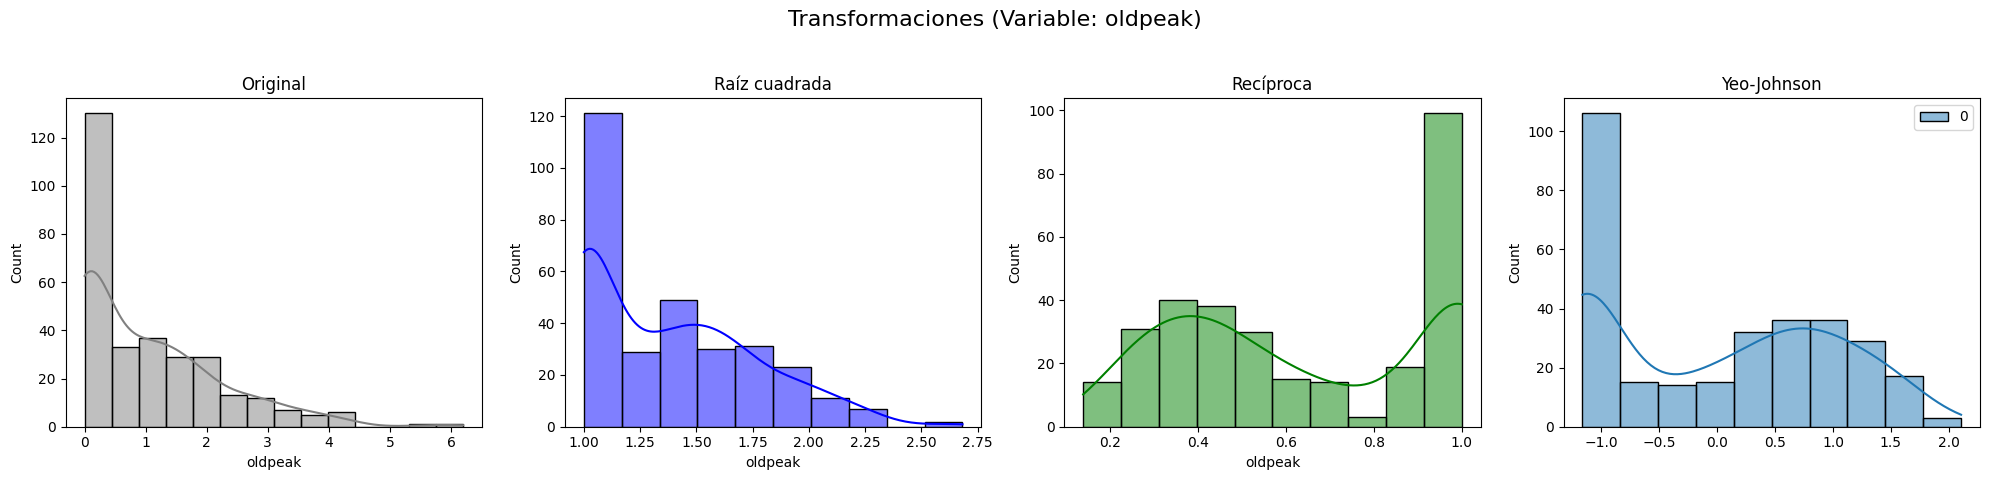

In [ ]:
# Gráfica
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Transformaciones (Variable: oldpeak)', fontsize=16)

# Original
sns.histplot(data, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')

# Raíz cuadrada
sns.histplot(sqrt_trans, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Raíz cuadrada')

# Recíproca
sns.histplot(reciprocal_trans, kde=True, ax=axes[2], color='green')
axes[2].set_title('Recíproca')

# Yeo-Johnson
sns.histplot(yeojohnson_trans, kde=True, ax=axes[3], color='red')
axes[3].set_title('Yeo-Johnson')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis:**
> Es notorio que los datos originales son asimétricos. La transformación por raíz cuadrada trata levemente de mejorar esto pero no logra un cambio significativo, mientras que la transformación recíproca y la Yeo-Johnson son las que mejor tratan de normalizar los datos. Entre estas Yeo-Johnson es la que más trata de mantener la forma real de los datos por lo que es la más recomendada para utilizar.